# OPTIMISASI MODEL K-NEAREST NEIGHBOR (KNN) DALAM MEMPREDIKSI TINGKAT KEPARAHAN KECELAKAAN LALU LINTAS


# NAMA : Muhammad Alpi Ashari


## 1. Import Library

Pada tahap ini dilakukan import library yang digunakan dalam penelitian, meliputi pengolahan data, visualisasi, preprocessing, serta pemodelan machine learning.

In [57]:
!pip install openpyxl
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
import scipy.stats as stats

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Dataset

In [58]:
df = pd.read_csv('RTA Dataset.csv')
df

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury


In [59]:
print(f"Jumlah total data: {df.shape[0]} baris dan {df.shape[1]} kolom")
print("\nInformasi DataFrame:")
df.info()

Jumlah total data: 12316 baris dan 32 kolom

Informasi DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians      

## 3. Preprocessing

Tahap preprocessing bertujuan untuk memastikan kualitas data sebelum digunakan dalam pemodelan.

### A. Pengeckan Nilai null

In [60]:
print("Jumlah Null per Kolom:")
print(df.isnull().sum())

Jumlah Null per Kolom:
Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_

### B. Pembersihan Nilai Null

In [61]:
# Pisahkan kolom
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Imputer
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Terapkan
df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Cek ulang
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,0
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Service_year_of_vehicle,0


### C. Pengecekan Nilai Duplikat

In [62]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


### D. Pembersihan Data Duplikat

In [63]:
df = df.drop_duplicates()
print("Data setelah hapus duplikat:", df.shape)

Data setelah hapus duplikat: (12316, 32)


### E. Outlier (Z-Score)

1. Pengecekan Outlier

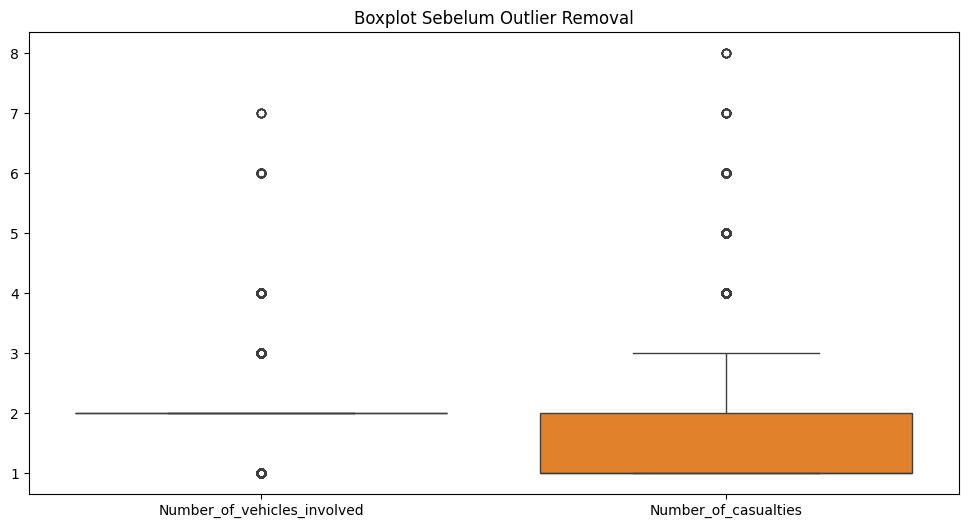

In [64]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Boxplot Sebelum Outlier Removal")
plt.show()

2. Penghapusan Outlier

In [65]:

numeric_cols = df.select_dtypes(include=np.number).columns

z_scores = np.abs(stats.zscore(df[numeric_cols]))
df = df[(z_scores < 3).all(axis=1)]

print("Data setelah hapus outlier:", df.shape)

Data setelah hapus outlier: (11941, 32)


3. Pengecekan sesudah pembersihan Outier

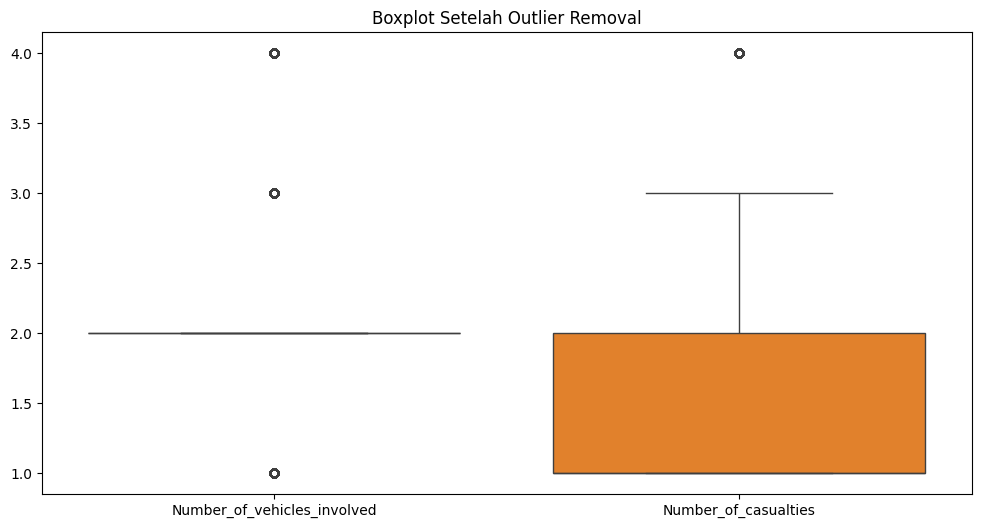

In [66]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Boxplot Setelah Outlier Removal")
plt.show()

## 4. Transformasi Data

Data kategorikal diubah menjadi numerik menggunakan Label Encoding.

In [67]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,418,1,0,1,0,0,0,0,3,3,...,2,3,2,5,3,0,2,5,9,2
1,418,1,1,1,4,0,3,11,3,2,...,2,3,2,5,3,0,2,5,16,2
2,418,1,0,1,4,0,0,5,3,5,...,2,0,1,1,2,0,2,5,0,1
3,592,3,0,1,4,0,2,11,0,5,...,2,2,0,0,2,0,2,5,1,2
4,592,3,0,1,4,0,1,0,3,2,...,2,3,2,5,3,0,2,5,16,2


## 7. Exploratory Data Analysis (EDA)

Menampilkan distribusi data di dalam dataset

### A. Distribusi (*weather*)

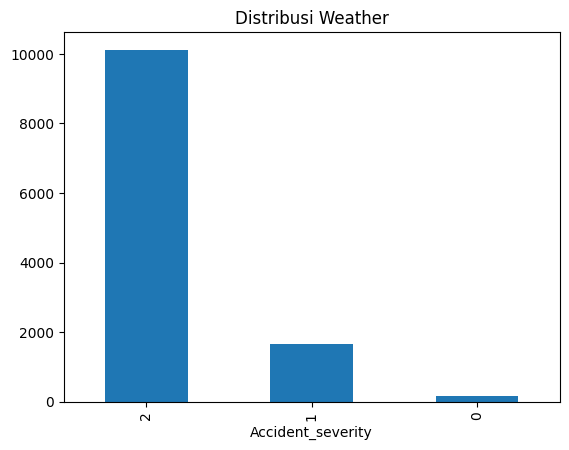

In [68]:
df['Accident_severity'].value_counts().plot(kind='bar')
plt.title("Distribusi Weather")
plt.show()

### B. Distribusi (*Accident*)

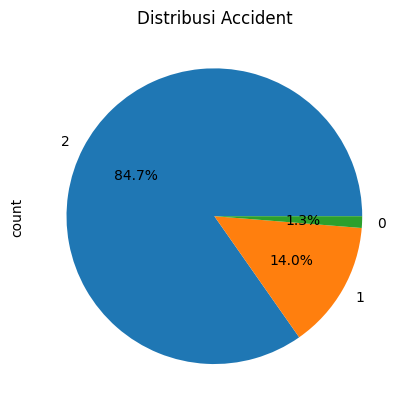

In [69]:
df['Accident_severity'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribusi Accident")
plt.show()

### C. Distribusi Keseluruhan

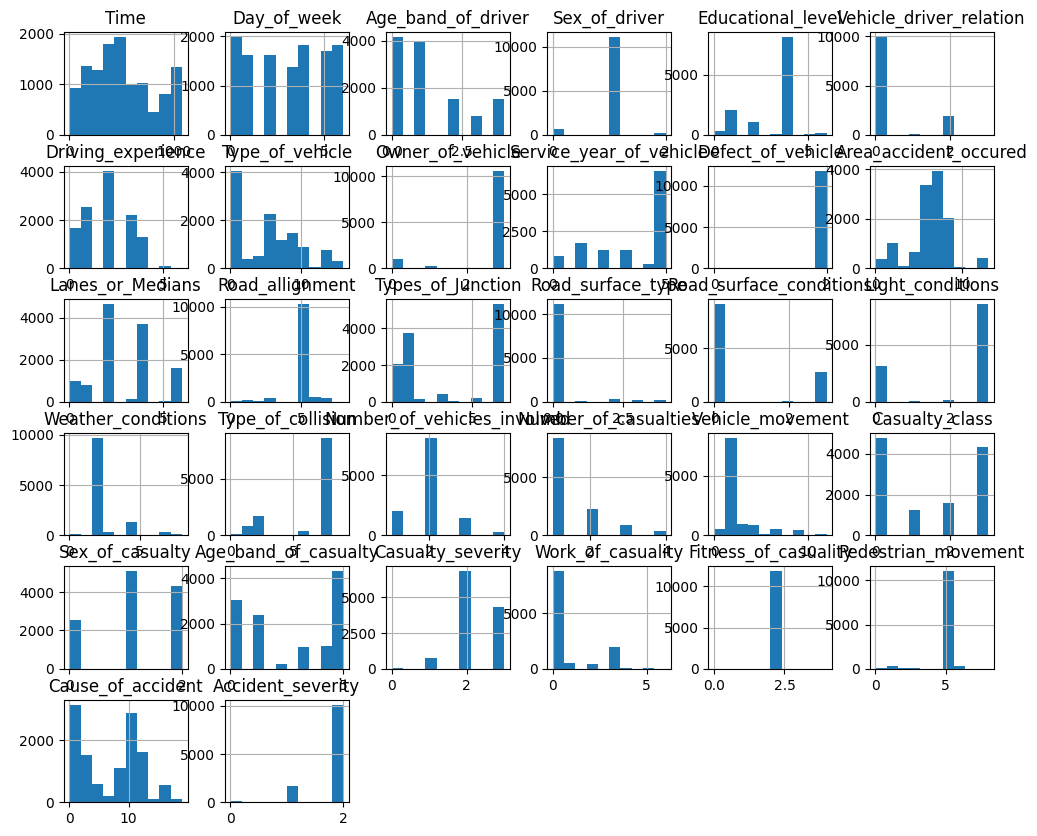

In [70]:
df.hist(figsize=(12,10))
plt.show()

### D. Korelasi antar dataset

In [71]:
X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

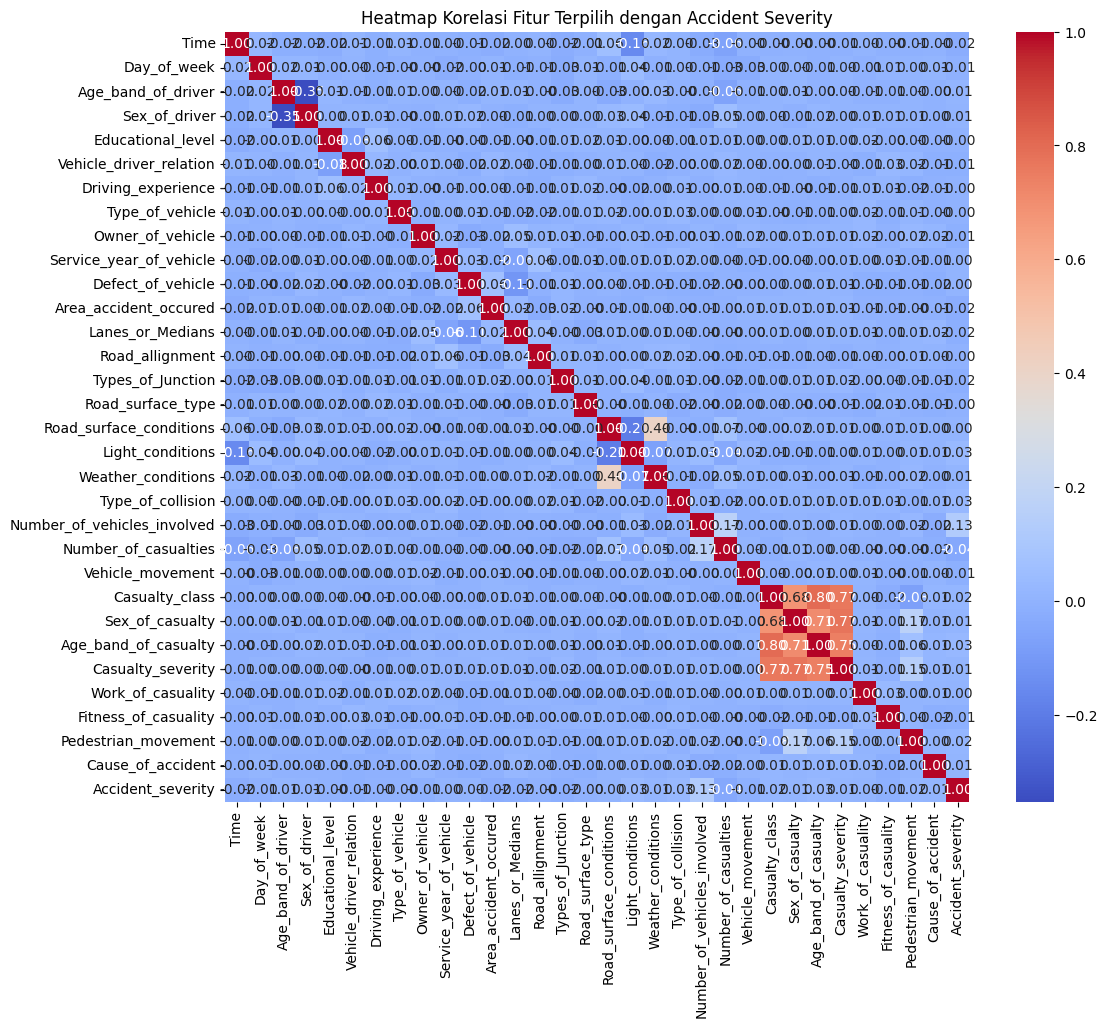

In [72]:
plt.figure(figsize=(12,10))
df_selected_with_target = pd.concat([X, y], axis=1)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Fitur Terpilih dengan Accident Severity")
plt.show()

## 8. Pengujian KNN

### A. Konfigurasi Pengujian

In [73]:
def evaluate_model(pipeline, X_selected, y, cv):

    scoring = {
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro'
    }

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    return {
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision_macro'].mean(),
        'Recall': scores['test_recall_macro'].mean(),
        'F1 Score': scores['test_f1_macro'].mean()
    }

### C. Pengujian K-Fold Terbaik (Non Smote)

In [74]:
kfold_list = [3, 5, 10]

In [75]:
hasil_kfold_non_smote = []

for kfold in kfold_list:

    cv = StratifiedKFold(
        n_splits=kfold,
        shuffle=True,
        random_state=42
    )

    pipeline = ImbPipeline([

        ('imputer', SimpleImputer(strategy='most_frequent')),

        ('scaler', MinMaxScaler()),

        ('knn', KNeighborsClassifier(
            n_neighbors=3,
            metric='euclidean',
            weights='uniform'
        ))
    ])

    hasil = evaluate_model(pipeline, X, y, cv)

    hasil['KFold'] = kfold

    hasil_kfold_non_smote.append(hasil)

df_kfold_non_smote = pd.DataFrame(hasil_kfold_non_smote)

df_kfold_non_smote

,Accuracy,Precision,Recall,F1 Score,KFold
0,0.811155,0.387792,0.364285,0.364369,3
1,0.813666,0.385041,0.359001,0.358811,5
2,0.811908,0.388937,0.360356,0.361297,10


### D. Pengujian K-fold Terbaik (SMOTE)

In [76]:
hasil_kfold_smote = []

for kfold in kfold_list:

    cv = StratifiedKFold(
        n_splits=kfold,
        shuffle=True,
        random_state=42
    )

    pipeline = ImbPipeline([

        ('imputer', SimpleImputer(strategy='most_frequent')),

        ('scaler', MinMaxScaler()),

        ('smote', SMOTE(random_state=42)),

        ('knn', KNeighborsClassifier(
            n_neighbors=3,
            metric='euclidean',
            weights='uniform'
        ))
    ])

    hasil = evaluate_model(pipeline, X, y, cv)

    hasil['KFold'] = kfold

    hasil_kfold_smote.append(hasil)

df_kfold_smote = pd.DataFrame(hasil_kfold_smote)

df_kfold_smote

,Accuracy,Precision,Recall,F1 Score,KFold
0,0.554560,0.362345,0.448263,0.343804,3
1,0.564192,0.366240,0.451262,0.348638,5
2,0.562602,0.364904,0.446376,0.347324,10


### E. Pegujian K tetangga Terbaik (Non SMOTE + K-Fold Terbaik Non SMOTE)

In [77]:
k_values = [3,5,7,9]

hasil_k_non_smote = []

df_kfold_non_smote['Avg_Score'] = (df_kfold_non_smote['Accuracy'] + df_kfold_non_smote['F1 Score']) / 2
best_kfold_non_smote = df_kfold_non_smote.loc[df_kfold_non_smote['Avg_Score'].idxmax()]['KFold']

cv = StratifiedKFold(
    n_splits=int(best_kfold_non_smote),
    shuffle=True,
    random_state=42
)

for k in k_values:

    pipeline = ImbPipeline([

        ('imputer', SimpleImputer(strategy='most_frequent')),

        ('scaler', MinMaxScaler()),

        ('knn', KNeighborsClassifier(
            n_neighbors=k,
            metric='euclidean',
            weights='uniform'
        ))
    ])

    hasil = evaluate_model(pipeline, X, y, cv)

    hasil['K'] = k

    hasil_k_non_smote.append(hasil)

df_k_non_smote = pd.DataFrame(hasil_k_non_smote)

df_k_non_smote

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Precision,Recall,F1 Score,K
0,0.811155,0.387792,0.364285,0.364369,3
1,0.832510,0.463727,0.349787,0.345745,5
2,0.840884,0.478819,0.339298,0.322620,7
3,0.844402,0.360408,0.334875,0.311311,9


In [78]:
df_k_non_smote['Avg_Score'] = (df_k_non_smote['Accuracy'] + df_k_non_smote['F1 Score']) / 2
best_k_non_smote = df_k_non_smote.sort_values(
    by='Avg_Score',
    ascending=False
).iloc[0]['K']

print("K terbaik:", best_k_non_smote)

K terbaik: 5.0


### F. Pengujian K Tetangga Terbaik (SMOTE + K-Fold Terbaik SMOTE)

In [79]:
df_kfold_smote['Avg_Score'] = (df_kfold_smote['Accuracy'] + df_kfold_smote['F1 Score']) / 2
best_kfold_smote = df_kfold_smote.loc[df_kfold_smote['Avg_Score'].idxmax()]['KFold']

hasil_k_smote = []

cv_smote = StratifiedKFold(
    n_splits=int(best_kfold_smote),
    shuffle=True,
    random_state=42
)

for k in k_values:

    pipeline = ImbPipeline([

        ('imputer', SimpleImputer(strategy='most_frequent')),

        ('scaler', MinMaxScaler()),

        ('smote', SMOTE(random_state=42)),

        ('knn', KNeighborsClassifier(
            n_neighbors=k,
            metric='euclidean',
            weights='uniform'
        ))
    ])

    hasil = evaluate_model(pipeline, X, y, cv_smote)

    hasil['K'] = k

    hasil_k_smote.append(hasil)

df_k_smote = pd.DataFrame(hasil_k_smote)

df_k_smote

,Accuracy,Precision,Recall,F1 Score,K
0,0.564192,0.366240,0.451262,0.348638,3
1,0.507998,0.363831,0.458861,0.328444,5
2,0.465288,0.361019,0.459898,0.310857,7
3,0.434302,0.359411,0.460692,0.297217,9


In [80]:
df_k_smote['Avg_Score'] = (df_k_smote['Accuracy'] + df_k_smote['F1 Score']) / 2
best_k_smote = df_k_smote.sort_values(
    by='Avg_Score',
    ascending=False
).iloc[0]['K']

print("K terbaik:", best_k_smote)

K terbaik: 3.0


### G. Uji Metode Jarak(Non SMOTE + K-FOld Terbaik Non SMOTE + K Tetangga Terbaik Non SMOTE)

In [81]:
metric_list = ['euclidean', 'manhattan']

hasil_metric_non_smote = []

for metric in metric_list:

    pipeline = ImbPipeline([

        ('imputer', SimpleImputer(strategy='most_frequent')),

        ('scaler', MinMaxScaler()),

        ('knn', KNeighborsClassifier(
            n_neighbors=int(best_k_non_smote),
            metric=metric,
            weights='uniform'
        ))
    ])

    hasil = evaluate_model(pipeline, X, y, cv)

    hasil['Metric'] = metric

    hasil_metric_non_smote.append(hasil)

df_metric_non_smote = pd.DataFrame(hasil_metric_non_smote)

df_metric_non_smote

,Accuracy,Precision,Recall,F1 Score,Metric
0,0.832510,0.463727,0.349787,0.345745,euclidean
1,0.832677,0.419361,0.346393,0.339266,manhattan


In [82]:
df_metric_non_smote['Avg_Score'] = (df_metric_non_smote['Accuracy'] + df_metric_non_smote['F1 Score']) / 2
best_metric_non_smote = df_metric_non_smote.sort_values(
    by='Avg_Score',
    ascending=False
).iloc[0]['Metric']

print("Metric terbaik:", best_metric_non_smote)

Metric terbaik: euclidean


### H. Uji Metode Jarak (SMOTE + K-FOld Terbaik SMOTE + K Tetangga Terbaik SMOTE)

In [83]:
hasil_metric_smote = []

for metric in metric_list:

    pipeline = ImbPipeline([

        ('imputer', SimpleImputer(strategy='most_frequent')),

        ('scaler', MinMaxScaler()),

        ('smote', SMOTE(random_state=42)),

        ('knn', KNeighborsClassifier(
            n_neighbors=int(best_k_smote),
            metric=metric,
            weights='uniform'
        ))
    ])

    hasil = evaluate_model(pipeline, X, y, cv_smote)

    hasil['Metric'] = metric

    hasil_metric_smote.append(hasil)

df_metric_smote = pd.DataFrame(hasil_metric_smote)

df_metric_smote

,Accuracy,Precision,Recall,F1 Score,Metric
0,0.564192,0.366240,0.451262,0.348638,euclidean
1,0.686626,0.381987,0.427625,0.390363,manhattan


In [84]:
df_metric_smote['Avg_Score'] = (df_metric_smote['Accuracy'] + df_metric_smote['F1 Score']) / 2
best_metric_smote = df_metric_smote.sort_values(
    by='Avg_Score',
    ascending=False
).iloc[0]['Metric']

print("Metric terbaik:", best_metric_smote)

Metric terbaik: manhattan


### I. Pengujian Weights Bobot Terbaik ( Non SMOTE + K-FOLD Terbaik Non SMOTE + K Tetangga Terbaik Non SMOTE + Metode Jarak Terbaik Non SMOTE)

In [85]:
weight_list = ['uniform', 'distance']

hasil_weight_non_smote = []

for weight in weight_list:

    pipeline = ImbPipeline([

        ('imputer', SimpleImputer(strategy='most_frequent')),

        ('scaler', MinMaxScaler()),

        ('knn', KNeighborsClassifier(
            n_neighbors=int(best_k_non_smote),
            metric=best_metric_non_smote,
            weights=weight
        ))
    ])

    hasil = evaluate_model(pipeline, X, y, cv)

    hasil['Weight'] = weight

    hasil_weight_non_smote.append(hasil)

df_weight_non_smote = pd.DataFrame(hasil_weight_non_smote)

df_weight_non_smote

,Accuracy,Precision,Recall,F1 Score,Weight
0,0.832510,0.463727,0.349787,0.345745,uniform
1,0.833766,0.477910,0.347969,0.342228,distance


In [86]:
df_weight_non_smote['Avg_Score'] = (df_weight_non_smote['Accuracy'] + df_weight_non_smote['F1 Score']) / 2
best_weight_non_smote = df_weight_non_smote.sort_values(
    by='Avg_Score',
    ascending=False
).iloc[0]['Weight']

print("KFold :", best_kfold_non_smote)
print("K :", best_k_non_smote)
print("Metric :", best_metric_non_smote)
print("Weight :", best_weight_non_smote)

KFold : 3.0
K : 5.0
Metric : euclidean
Weight : uniform


### J. Pengujian Weights Bobot Terbaik ( SMOTE + K-FOLD Terbaik SMOTE + K Tetangga Terbaik SMOTE + Metode Jarak Terbaik SMOTE)

In [87]:
hasil_weight_smote = []

for weight in weight_list:

    pipeline = ImbPipeline([

        ('imputer', SimpleImputer(strategy='most_frequent')),

        ('scaler', MinMaxScaler()),

        ('smote', SMOTE(random_state=42)),

        ('knn', KNeighborsClassifier(
            n_neighbors=int(best_k_smote),
            metric=best_metric_smote,
            weights=weight
        ))
    ])

    hasil = evaluate_model(pipeline, X, y, cv_smote)

    hasil['Weight'] = weight

    hasil_weight_smote.append(hasil)

df_weight_smote = pd.DataFrame(hasil_weight_smote)

df_weight_smote

,Accuracy,Precision,Recall,F1 Score,Weight
0,0.686626,0.381987,0.427625,0.390363,uniform
1,0.688049,0.381614,0.423711,0.389525,distance


In [88]:
df_weight_smote['Avg_Score'] = (df_weight_smote['Accuracy'] + df_weight_smote['F1 Score']) / 2
best_weight_smote = df_weight_smote.sort_values(
    by='Avg_Score',
    ascending=False
).iloc[0]['Weight']

print("KFold :", best_kfold_smote)
print("K :", best_k_smote)
print("Metric :", best_metric_smote)
print("Weight :", best_weight_smote)

KFold : 5.0
K : 3.0
Metric : manhattan
Weight : distance


### K. Pengujian Dummy Baseline

Dummy Classifier Results:


,Accuracy,Precision,Recall,F1 Score
0,0.847249,0.282416,0.333333,0.30577



Confusion Matrix for Dummy Classifier:


,Predicted 0,Predicted 1,Predicted 2
Actual 0,0,0,16
Actual 1,0,0,167
Actual 2,0,0,1012


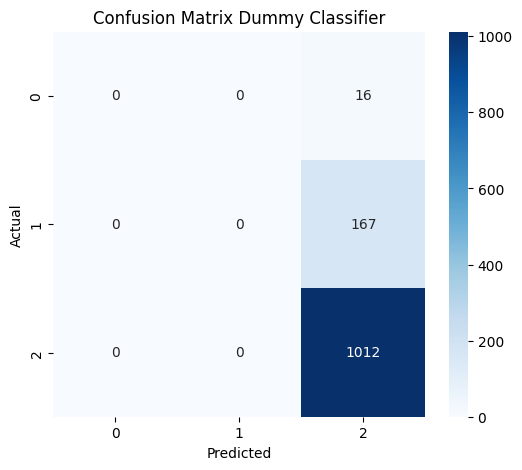


Classification Report Dummy Classifier:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
0,0.00000,0.00000,0.00000,16
1,0.00000,0.00000,0.00000,167
2,0.84686,1.00000,0.91708,1012
accuracy,0.84686,0.84686,0.84686,0
macro avg,0.28229,0.33333,0.30569,1195
weighted avg,0.71718,0.84686,0.77664,1195


In [113]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

dummy_pipeline = ImbPipeline([

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('scaler', MinMaxScaler()),

    ('dummy', DummyClassifier(strategy='most_frequent'))
])

cv_dummy = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
    dummy_result = evaluate_model(
        dummy_pipeline,
        X,
        y,
        cv_dummy
    )

df_dummy_result = pd.DataFrame([dummy_result])
print("Dummy Classifier Results:")
display(df_dummy_result)

# --- Add Confusion Matrix for Dummy Classifier ---
print("\nConfusion Matrix for Dummy Classifier:")

# Perform a single split to get y_test and y_pred for visualization
# Using the first split from cv_dummy for consistency with other parts of the notebook
for train_index, test_index in cv_dummy.split(X, y):
    X_train_dummy, X_test_dummy = X.iloc[train_index], X.iloc[test_index]
    y_train_dummy, y_test_dummy = y.iloc[train_index], y.iloc[test_index]
    break # We only need one split for the confusion matrix

# Fit the dummy pipeline and make predictions
dummy_pipeline.fit(X_train_dummy, y_train_dummy)
y_pred_dummy = dummy_pipeline.predict(X_test_dummy)

# Calculate and print the confusion matrix values
cm_dummy = confusion_matrix(y_test_dummy, y_pred_dummy)

# Get unique classes from y_test and y_pred to use as labels
classes_dummy = np.unique(np.concatenate((y_test_dummy, y_pred_dummy)))

# Create a DataFrame for the confusion matrix
cm_df_dummy = pd.DataFrame(cm_dummy, index=['Actual ' + str(c) for c in classes_dummy], columns=['Predicted ' + str(c) for c in classes_dummy])

display(cm_df_dummy)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_dummy,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Confusion Matrix Dummy Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Add Classification Report for Dummy Classifier ---
report_dummy = classification_report(y_test_dummy, y_pred_dummy, output_dict=True)

df_report_dummy = pd.DataFrame(report_dummy).transpose()

# Format numerical columns to 5 decimal places
for col in ['precision', 'recall', 'f1-score', 'support']:
    if col in df_report_dummy.columns:
        if col == 'support': # Support column should be integer
            df_report_dummy[col] = df_report_dummy[col].astype(int)
        else:
            df_report_dummy[col] = df_report_dummy[col].apply(lambda x: f'{x:.5f}')

print("\nClassification Report Dummy Classifier:")
display(df_report_dummy)

### L. Model Final Non-SMOTE

In [90]:
final_pipeline_non_smote = ImbPipeline([

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('scaler', MinMaxScaler()),

    ('knn', KNeighborsClassifier(

        n_neighbors=int(best_k_non_smote),

        metric=best_metric_non_smote,

        weights=best_weight_non_smote
    ))
])

### M. Model Final SMOTE

In [91]:
final_pipeline_smote = ImbPipeline([

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('scaler', MinMaxScaler()),

    ('smote', SMOTE(random_state=42)),

    ('knn', KNeighborsClassifier(

        n_neighbors=int(best_k_smote),

        metric=best_metric_smote,

        weights=best_weight_smote
    ))
])

### N.Prediksi Final Non-SMOTE

In [92]:
cv_final_non_smote = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

for train_index_non_smote, test_index_smote in cv_final_non_smote.split(X, y):

    X_Train_non_smote = X.iloc[train_index_non_smote]
    X_Test_non_smote = X.iloc[test_index_smote]

    y_train_non_smote = y.iloc[train_index_non_smote]
    y_test_non_smote = y.iloc[test_index_smote]

    final_pipeline_non_smote.fit(X_Train_non_smote, y_train_non_smote)

    y_pred_non_smote = final_pipeline_non_smote.predict(X_Test_non_smote) # Changed to non_smote for prediction

    break

### O.Prediksi Final SMOTE

In [93]:
cv_final_smote = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

for train_index_smote, test_index_smote in cv_final_smote.split(X, y):

    X_Train_smote = X.iloc[train_index_smote]
    X_Test_smote = X.iloc[test_index_smote]

    y_train_smote = y.iloc[train_index_smote]
    y_test_smote = y.iloc[test_index_smote]

    final_pipeline_smote.fit(X_Train_smote, y_train_smote)

    y_pred_smote = final_pipeline_smote.predict(X_Test_smote) # Changed to non_smote for prediction

    break

### P. Confussion Matrix dan Classification Reprot Non-SMOTE

Confusion Matrix Non-SMOTE Model:


,Predicted 0,Predicted 1,Predicted 2
Actual 0,1,0,15
Actual 1,0,4,163
Actual 2,3,20,989


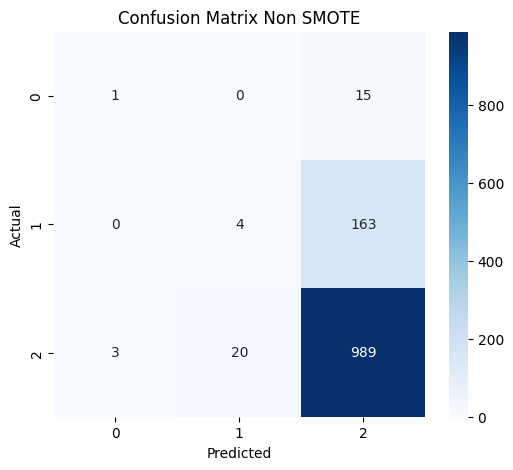

In [94]:
from IPython.display import display

cm = confusion_matrix(y_test_non_smote, y_pred_non_smote)

# Get unique classes from y_test and y_pred to use as labels
classes = np.unique(np.concatenate((y_test_non_smote, y_pred_non_smote)))

# Create a DataFrame for the confusion matrix
cm_df = pd.DataFrame(cm, index=['Actual ' + str(c) for c in classes], columns=['Predicted ' + str(c) for c in classes])

print("Confusion Matrix Non-SMOTE Model:")
display(cm_df)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Non SMOTE')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [114]:
report = classification_report(y_test_non_smote, y_pred_non_smote, output_dict=True)

df_report = pd.DataFrame(report).transpose()


for col in ['precision', 'recall', 'f1-score', 'support']:
    if col in df_report.columns:
        if col == 'support': # Support column should be integer
            df_report[col] = df_report[col].astype(int)
        else:
            df_report[col] = df_report[col].apply(lambda x: f'{x:.5f}')

print("Classification Report Non-SMOTE Model:")
display(df_report)


non_smote_macro_precision = float(df_report.loc['macro avg', 'precision'])
non_smote_macro_recall = float(df_report.loc['macro avg', 'recall'])
non_smote_macro_f1 = float(df_report.loc['macro avg', 'f1-score'])

print(f"\nMacro Average Precision (Non-SMOTE): {non_smote_macro_precision:.5f}")
print(f"Macro Average Recall (Non-SMOTE): {non_smote_macro_recall:.5f}")
print(f"Macro Average F1-Score (Non-SMOTE): {non_smote_macro_f1:.5f}")

Classification Report Non-SMOTE Model:


,precision,recall,f1-score,support
0,0.25000,0.06250,0.10000,16
1,0.16667,0.02395,0.04188,167
2,0.84747,0.97727,0.90776,1012
accuracy,0.83180,0.83180,0.83180,0
macro avg,0.42138,0.35457,0.34988,1195
weighted avg,0.74433,0.83180,0.77594,1195



Macro Average Precision (Non-SMOTE): 0.42138
Macro Average Recall (Non-SMOTE): 0.35457
Macro Average F1-Score (Non-SMOTE): 0.34988


### Q. Confussion Matrix SMOTE

Confusion Matrix SMOTE Model:


,Predicted 0,Predicted 1,Predicted 2
Actual 0,3,2,11
Actual 1,5,32,130
Actual 2,30,209,773


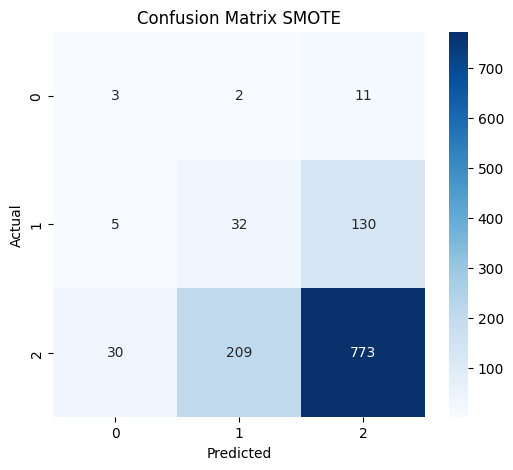

In [96]:
cm = confusion_matrix(y_test_smote, y_pred_smote)

# Get unique classes from y_test and y_pred to use as labels
classes_smote = np.unique(np.concatenate((y_test_smote, y_pred_smote)))

# Create a DataFrame for the confusion matrix
cm_df_smote = pd.DataFrame(cm, index=['Actual ' + str(c) for c in classes_smote], columns=['Predicted ' + str(c) for c in classes_smote])

print("Confusion Matrix SMOTE Model:")
display(cm_df_smote)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix SMOTE')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [115]:
report_smote = classification_report(y_test_smote, y_pred_smote, output_dict=True)

df_report_smote = pd.DataFrame(report_smote).transpose()

# Format numerical columns to 5 decimal places
for col in ['precision', 'recall', 'f1-score', 'support']:
    if col in df_report_smote.columns:
        if col == 'support': # Support column should be integer
            df_report_smote[col] = df_report_smote[col].astype(int)
        else:
            df_report_smote[col] = df_report_smote[col].apply(lambda x: f'{x:.5f}')

print("Classification Report SMOTE Model:")
display(df_report_smote)

# Store macro average scores into variables
smote_macro_precision = float(df_report_smote.loc['macro avg', 'precision'])
smote_macro_recall = float(df_report_smote.loc['macro avg', 'recall'])
smote_macro_f1 = float(df_report_smote.loc['macro avg', 'f1-score'])

print(f"\nMacro Average Precision (SMOTE): {smote_macro_precision:.5f}")
print(f"Macro Average Recall (SMOTE): {smote_macro_recall:.5f}")
print(f"Macro Average F1-Score (SMOTE): {smote_macro_f1:.5f}")

Classification Report SMOTE Model:


,precision,recall,f1-score,support
0,0.07895,0.18750,0.11111,16
1,0.13169,0.19162,0.15610,167
2,0.84573,0.76383,0.80270,1012
accuracy,0.67615,0.67615,0.67615,0
macro avg,0.35212,0.38098,0.35664,1195
weighted avg,0.73568,0.67615,0.70308,1195



Macro Average Precision (SMOTE): 0.35212
Macro Average Recall (SMOTE): 0.38098
Macro Average F1-Score (SMOTE): 0.35664


In [98]:
rekap = pd.DataFrame({

    'Metode': [
        'Dummy Baseline',
        'KNN Non-SMOTE',
        'KNN SMOTE'
    ],

    'Accuracy': [

        dummy_result['Accuracy'],

        df_weight_non_smote.sort_values(
            by='F1 Score',
            ascending=False
        ).iloc[0]['Accuracy'],

        df_weight_smote.sort_values(
            by='F1 Score',
            ascending=False
        ).iloc[0]['Accuracy']
    ],

    'Precision': [

        dummy_result['Precision'],

        df_weight_non_smote.sort_values(
            by='F1 Score',
            ascending=False
        ).iloc[0]['Precision'],

        df_weight_smote.sort_values(
            by='F1 Score',
            ascending=False
        ).iloc[0]['Precision']
    ],

    'Recall': [

        dummy_result['Recall'],

        df_weight_non_smote.sort_values(
            by='F1 Score',
            ascending=False
        ).iloc[0]['Recall'],

        df_weight_smote.sort_values(
            by='F1 Score',
            ascending=False
        ).iloc[0]['Recall']
    ],

    'F1 Macro': [

        dummy_result['F1 Score'],

        df_weight_non_smote.sort_values(
            by='F1 Score',
            ascending=False
        ).iloc[0]['F1 Score'],

        df_weight_smote.sort_values(
            by='F1 Score',
            ascending=False
        ).iloc[0]['F1 Score']
    ]
})

rekap

,Metode,Accuracy,Precision,Recall,F1 Macro
0,Dummy Baseline,0.847249,0.282416,0.333333,0.305770
1,KNN Non-SMOTE,0.832510,0.463727,0.349787,0.345745
2,KNN SMOTE,0.686626,0.381987,0.427625,0.390363


### K. Pengujan Kombinasi Grid Search CV (Non SMOTE)

In [99]:
from sklearn.feature_selection import SelectKBest, f_classif

# Pipeline Non-SMOTE
pipeline_non_smote = ImbPipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])

# Parameter Grid
param_grid_non_smote = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__metric': ['euclidean', 'manhattan'],
    'knn__weights': ['uniform', 'distance']
}

# Cross Validation
cv = StratifiedKFold(
    n_splits=int(best_kfold_non_smote), # Use the best KFold value determined earlier
    shuffle=True,
    random_state=42
)

# Grid Search
grid_non_smote = GridSearchCV(
    estimator=pipeline_non_smote,
    param_grid=param_grid_non_smote,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Training
grid_non_smote.fit(X, y)

# Hasil terbaik
print("BEST PARAMETER NON-SMOTE")
print(grid_non_smote.best_params_)

print("\nBEST F1 MACRO NON-SMOTE")
print(grid_non_smote.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
BEST PARAMETER NON-SMOTE
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}

BEST F1 MACRO NON-SMOTE
0.3777443715915752


In [100]:

hasil_grid_non_smote = pd.DataFrame(grid_non_smote.cv_results_)

hasil_grid_non_smote = hasil_grid_non_smote[[
    'param_knn__n_neighbors',
    'param_knn__metric',
    'param_knn__weights',
    'mean_test_score',
    'rank_test_score'
]]

hasil_grid_non_smote['KFold'] = int(best_kfold_non_smote)

hasil_grid_non_smote = hasil_grid_non_smote.sort_values(
    by='rank_test_score'
)

hasil_grid_non_smote.head(10)

,param_knn__n_neighbors,param_knn__metric,param_knn__weights,mean_test_score,rank_test_score,KFold
9,3,manhattan,distance,0.377744,1,3
8,3,manhattan,uniform,0.374762,2,3
1,3,euclidean,distance,0.371352,3,3
0,3,euclidean,uniform,0.364369,4,3
2,5,euclidean,uniform,0.345745,5,3
3,5,euclidean,distance,0.342228,6,3
10,5,manhattan,uniform,0.339266,7,3
11,5,manhattan,distance,0.331245,8,3
12,7,manhattan,uniform,0.323872,9,3
4,7,euclidean,uniform,0.322620,10,3


### L. Pengujan Kombinasi Grid Search CV (SMOTE)

In [101]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif # Keep import if f_classif is used elsewhere

# Pipeline SMOTE
pipeline_smote = ImbPipeline([
    # Removed feature selection step
    ('scaler', MinMaxScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

# Parameter Grid
param_grid_smote = {
    # Removed 'feature_selection__k'
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__metric': ['euclidean', 'manhattan'],
    'knn__weights': ['uniform', 'distance']
}

# Cross Validation
cv = StratifiedKFold(
    n_splits=int(best_kfold_smote),
    shuffle=True,
    random_state=42
)

# Grid Search
grid_smote = GridSearchCV(
    estimator=pipeline_smote,
    param_grid=param_grid_smote,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Training
grid_smote.fit(X, y)

# Hasil terbaik
print("BEST PARAMETER SMOTE")
print(grid_smote.best_params_)

print("\nBEST F1 MACRO SMOTE")
print(grid_smote.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
BEST PARAMETER SMOTE
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}

BEST F1 MACRO SMOTE
0.39036308273197845


In [102]:
hasil_grid_smote = pd.DataFrame(grid_smote.cv_results_)

hasil_grid_smote = hasil_grid_smote[[
    'param_knn__n_neighbors',
    'param_knn__metric',
    'param_knn__weights',
    'mean_test_score',
    'rank_test_score'
]]

hasil_grid_smote['KFold'] = int(best_kfold_smote)

hasil_grid_smote = hasil_grid_smote.sort_values(
    by='rank_test_score'
)

hasil_grid_smote.head(10)

,param_knn__n_neighbors,param_knn__metric,param_knn__weights,mean_test_score,rank_test_score,KFold
8,3,manhattan,uniform,0.390363,1,5
9,3,manhattan,distance,0.389525,2,5
11,5,manhattan,distance,0.381290,3,5
10,5,manhattan,uniform,0.380664,4,5
13,7,manhattan,distance,0.374569,5,5
15,9,manhattan,distance,0.373892,6,5
12,7,manhattan,uniform,0.372416,7,5
14,9,manhattan,uniform,0.370781,8,5
1,3,euclidean,distance,0.351082,9,5
0,3,euclidean,uniform,0.348638,10,5


### N. Model Final Grid Search CV (Non SMOTE)

In [103]:
final_pipeline_non_smote = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=grid_non_smote.best_params_['knn__n_neighbors'],
        metric=grid_non_smote.best_params_['knn__metric'],
        weights=grid_non_smote.best_params_['knn__weights']
    ))
])

print("Final Non-SMOTE Model (GridSearchCV):")
print(final_pipeline_non_smote)

Final Non-SMOTE Model (GridSearchCV):
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('scaler', MinMaxScaler()),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=3,
                                      weights='distance'))])


### O. Model Final Grid Search CV ( SMOTE)

In [104]:
final_pipeline_smote_grid = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', MinMaxScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(
        n_neighbors=grid_smote.best_params_['knn__n_neighbors'],
        metric=grid_smote.best_params_['knn__metric'],
        weights=grid_smote.best_params_['knn__weights']
    ))
])

print("Final SMOTE Model (GridSearchCV):")
print(final_pipeline_smote_grid)

Final SMOTE Model (GridSearchCV):
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('scaler', MinMaxScaler()), ('smote', SMOTE(random_state=42)),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=3))])


### P. Prediksi Final Model Grid Search CV (NON SMOTE)

In [105]:
cv_final_non_smote = StratifiedKFold(
    n_splits=int(best_kfold_non_smote),
    shuffle=True,
    random_state=42
)

for train_index, test_index in cv_final_non_smote.split(X, y):

    X_Train_non_smote_final = X.iloc[train_index]
    X_Test_non_smote_final = X.iloc[test_index]

    y_train_non_smote_final = y.iloc[train_index]
    y_test_non_smote_final = y.iloc[test_index]

    final_pipeline_non_smote.fit(X_Train_non_smote_final, y_train_non_smote_final)

    y_pred_non_smote_final = final_pipeline_non_smote.predict(X_Test_non_smote_final)

    break


### Q. Prediksi Final Model Grid Search CV (SMOTE)

In [106]:
cv_final_smote_grid = StratifiedKFold(
    n_splits=int(best_kfold_smote),
    shuffle=True,
    random_state=42
)

for train_index_smote_final, test_index_smote_final in cv_final_smote_grid.split(X, y):

    X_Train_smote_final = X.iloc[train_index_smote_final]
    X_Test_smote_final = X.iloc[test_index_smote_final]

    y_train_smote_final = y.iloc[train_index_smote_final]
    y_test_smote_final = y.iloc[test_index_smote_final]

    final_pipeline_smote_grid.fit(X_Train_smote_final, y_train_smote_final)

    y_pred_smote_final = final_pipeline_smote_grid.predict(X_Test_smote_final)

    break

### R. CONFUSSION MATRIX DAN CLASSIFICATION REPORT MODEL GRID SEARCH CV (NON SMOTE)

Confusion Matrix Non-SMOTE Grid Search CV Model:


,Predicted 0,Predicted 1,Predicted 2
Actual 0,5,4,42
Actual 1,1,49,507
Actual 2,12,143,3218


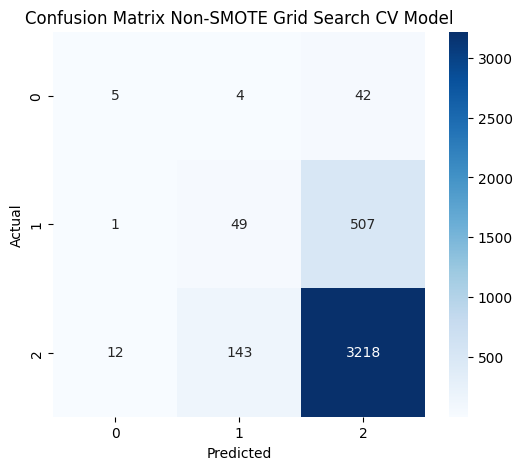

In [107]:
cm_non_smote_grid = confusion_matrix(y_test_non_smote_final, y_pred_non_smote_final)

# Get unique classes from y_test and y_pred to use as labels
classes_non_smote_grid = np.unique(np.concatenate((y_test_non_smote_final, y_pred_non_smote_final)))

# Create a DataFrame for the confusion matrix
cm_df_non_smote_grid = pd.DataFrame(cm_non_smote_grid, index=['Actual ' + str(c) for c in classes_non_smote_grid], columns=['Predicted ' + str(c) for c in classes_non_smote_grid])

print("Confusion Matrix Non-SMOTE Grid Search CV Model:")
display(cm_df_non_smote_grid)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_non_smote_grid,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Non-SMOTE Grid Search CV Model')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [116]:
report_non_smote_grid = classification_report(y_test_non_smote_final, y_pred_non_smote_final, output_dict=True)

df_report_non_smote_grid = pd.DataFrame(report_non_smote_grid).transpose()

# Format numerical columns to 5 decimal places
for col in ['precision', 'recall', 'f1-score', 'support']:
    if col in df_report_non_smote_grid.columns:
        if col == 'support': # Support column should be integer
            df_report_non_smote_grid[col] = df_report_non_smote_grid[col].astype(int)
        else:
            df_report_non_smote_grid[col] = df_report_non_smote_grid[col].apply(lambda x: f'{x:.5f}')

print("Classification Report Non-SMOTE Grid Search CV Model:")
display(df_report_non_smote_grid)

# Store macro average scores into variables
non_smote_grid_macro_precision = float(df_report_non_smote_grid.loc['macro avg', 'precision'])
non_smote_grid_macro_recall = float(df_report_non_smote_grid.loc['macro avg', 'recall'])
non_smote_grid_macro_f1 = float(df_report_non_smote_grid.loc['macro avg', 'f1-score'])

print(f"\nMacro Average Precision (Non-SMOTE Grid Search CV): {non_smote_grid_macro_precision:.5f}")
print(f"Macro Average Recall (Non-SMOTE Grid Search CV): {non_smote_grid_macro_recall:.5f}")
print(f"Macro Average F1-Score (Non-SMOTE Grid Search CV): {non_smote_grid_macro_f1:.5f}")

Classification Report Non-SMOTE Grid Search CV Model:


,precision,recall,f1-score,support
0,0.27778,0.09804,0.14493,51
1,0.25000,0.08797,0.13015,557
2,0.85426,0.95405,0.90140,3373
accuracy,0.82190,0.82190,0.82190,0
macro avg,0.46068,0.38002,0.39216,3981
weighted avg,0.76233,0.82190,0.78380,3981



Macro Average Precision (Non-SMOTE Grid Search CV): 0.46068
Macro Average Recall (Non-SMOTE Grid Search CV): 0.38002
Macro Average F1-Score (Non-SMOTE Grid Search CV): 0.39216


### S. CONFUSSION MATRIX DAN CLASSIFICATION REPORT MODEL GRID SEARCH CV (SMOTE)

Confusion Matrix SMOTE Grid Search CV Model:


,Predicted 0,Predicted 1,Predicted 2
Actual 0,8,7,16
Actual 1,11,88,235
Actual 2,57,415,1552


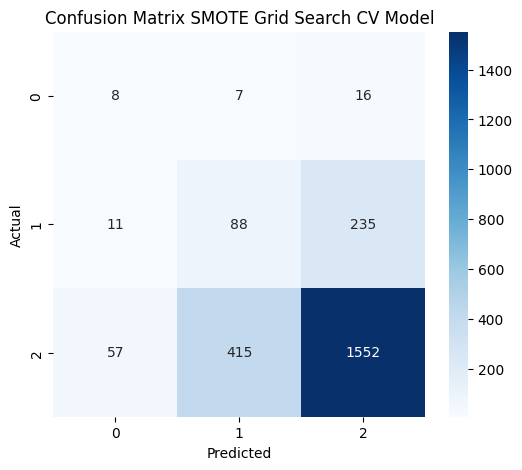

In [109]:
cm_smote_grid = confusion_matrix(y_test_smote_final, y_pred_smote_final)

# Get unique classes from y_test and y_pred to use as labels
classes_smote_grid = np.unique(np.concatenate((y_test_smote_final, y_pred_smote_final)))

# Create a DataFrame for the confusion matrix
cm_df_smote_grid = pd.DataFrame(cm_smote_grid, index=['Actual ' + str(c) for c in classes_smote_grid], columns=['Predicted ' + str(c) for c in classes_smote_grid])

print("Confusion Matrix SMOTE Grid Search CV Model:")
display(cm_df_smote_grid)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_smote_grid,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix SMOTE Grid Search CV Model')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [117]:
report_smote_grid = classification_report(y_test_smote_final, y_pred_smote_final, output_dict=True)

df_report_smote_grid = pd.DataFrame(report_smote_grid).transpose()

# Format numerical columns to 5 decimal places
for col in ['precision', 'recall', 'f1-score', 'support']:
    if col in df_report_smote_grid.columns:
        if col == 'support': # Support column should be integer
            df_report_smote_grid[col] = df_report_smote_grid[col].astype(int)
        else:
            df_report_smote_grid[col] = df_report_smote_grid[col].apply(lambda x: f'{x:.5f}')

print("Classification Report SMOTE Grid Search CV Model:")
display(df_report_smote_grid)

# Store macro average scores into variables
smote_grid_macro_precision = float(df_report_smote_grid.loc['macro avg', 'precision'])
smote_grid_macro_recall = float(df_report_smote_grid.loc['macro avg', 'recall'])
smote_grid_macro_f1 = float(df_report_smote_grid.loc['macro avg', 'f1-score'])

print(f"\nMacro Average Precision (SMOTE Grid Search CV): {smote_grid_macro_precision:.5f}")
print(f"Macro Average Recall (SMOTE Grid Search CV): {smote_grid_macro_recall:.5f}")
print(f"Macro Average F1-Score (SMOTE Grid Search CV): {smote_grid_macro_f1:.5f}")

Classification Report SMOTE Grid Search CV Model:


,precision,recall,f1-score,support
0,0.10526,0.25806,0.14953,31
1,0.17255,0.26347,0.20853,334
2,0.86079,0.76680,0.81108,2024
accuracy,0.68983,0.68983,0.68983,0
macro avg,0.37953,0.42945,0.38971,2389
weighted avg,0.75476,0.68983,0.71825,2389



Macro Average Precision (SMOTE Grid Search CV): 0.37953
Macro Average Recall (SMOTE Grid Search CV): 0.42945
Macro Average F1-Score (SMOTE Grid Search CV): 0.38971


In [120]:
comparison_data = {
    'Metode': [
        'Dummy Baseline',
        'Manual KNN Non-SMOTE',
        'Manual KNN SMOTE',
        'GridSearchCV Non-SMOTE',
        'GridSearchCV SMOTE'
    ],
    'Accuracy': [
        float(report_dummy['accuracy']),
        float(report['accuracy']),
        float(report_smote['accuracy']),
        float(report_non_smote_grid['accuracy']),
        float(report_smote_grid['accuracy'])
    ],
    'Precision': [
        float(df_report_dummy.loc['macro avg', 'precision']),
        non_smote_macro_precision,
        smote_macro_precision,
        non_smote_grid_macro_precision,
        smote_grid_macro_precision
    ],
    'Recall': [
        float(df_report_dummy.loc['macro avg', 'recall']),
        non_smote_macro_recall,
        smote_macro_recall,
        non_smote_grid_macro_recall,
        smote_grid_macro_recall
    ],
    'F1 Macro': [
        float(df_report_dummy.loc['macro avg', 'f1-score']),
        non_smote_macro_f1,
        smote_macro_f1,
        non_smote_grid_macro_f1,
        smote_grid_macro_f1
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison

,Metode,Accuracy,Precision,Recall,F1 Macro
0,Dummy Baseline,0.846862,0.28229,0.33333,0.30569
1,Manual KNN Non-SMOTE,0.831799,0.42138,0.35457,0.34988
2,Manual KNN SMOTE,0.676151,0.35212,0.38098,0.35664
3,GridSearchCV Non-SMOTE,0.821904,0.46068,0.38002,0.39216
4,GridSearchCV SMOTE,0.689828,0.37953,0.42945,0.38971


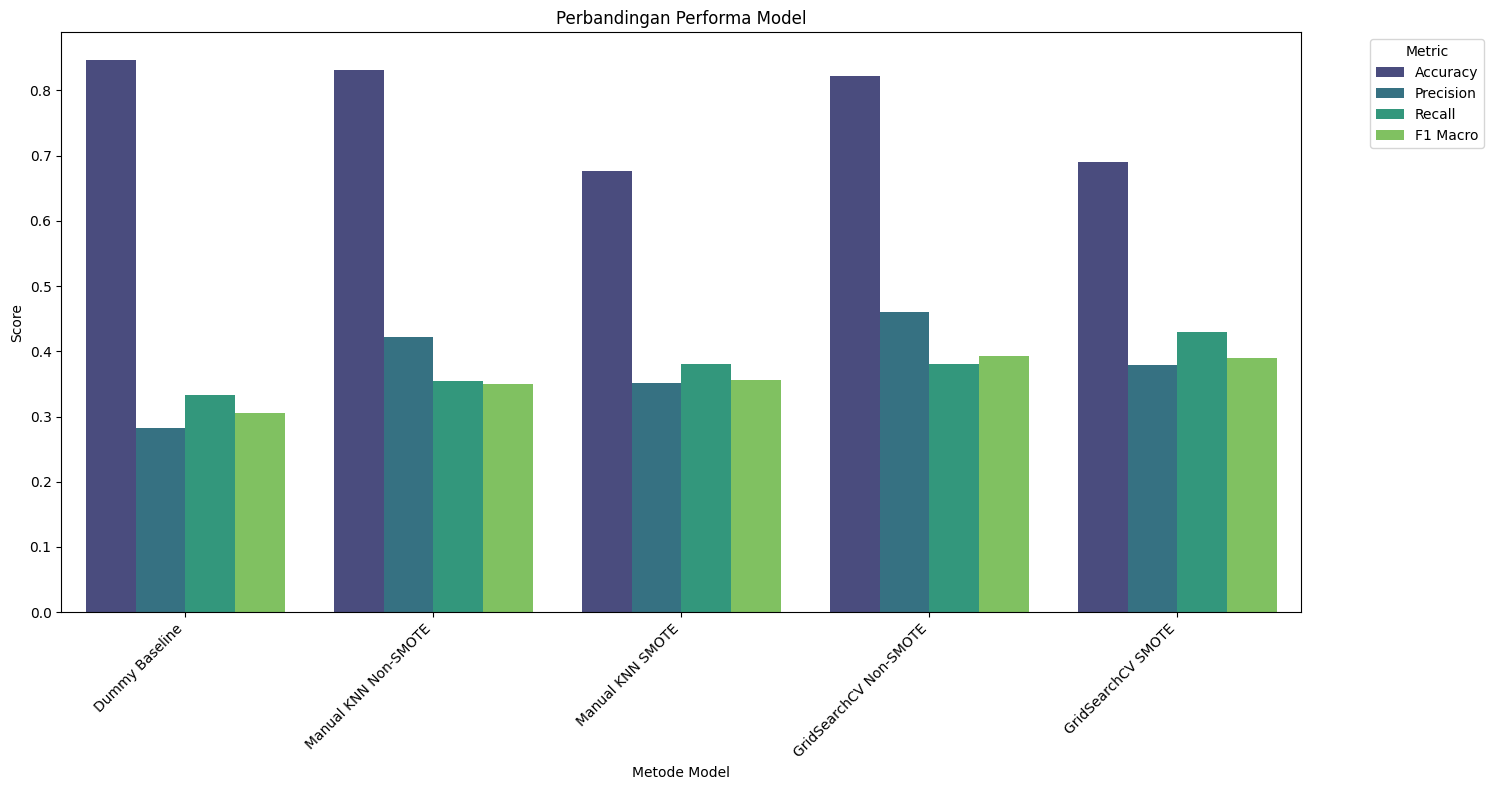

In [121]:
df_comparison_melted = df_comparison.melt(id_vars='Metode', var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 8))
sns.barplot(data=df_comparison_melted, x='Metode', y='Score', hue='Metric', palette='viridis')
plt.title('Perbandingan Performa Model')
plt.ylabel('Score')
plt.xlabel('Metode Model')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()